In [7]:
!pip install tqdm
!pip install -U scikit-image
!pip install split-folders

In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import cv2
import splitfolders
import pandas as pd
import numpy as np
from skimage.feature import local_binary_pattern
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [9]:
IMAGES_FOLDERS_PATH = '/kaggle/input/datasets/emmarex/plantdisease/PlantVillage'
OUTPUT_FOLDER = 'plantdisease_split'
WIDTH = 224
HEIGHT = 224
CHANNELS = 3
LBP_RADIUS   = 3
LBP_N_POINTS = 8 * LBP_RADIUS
LBP_METHOD   = 'uniform'


Image distribution across classes:
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3209
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                        Tomato_Early_blight   1000
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
              Pepper__bell___Bacterial_spot    997
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


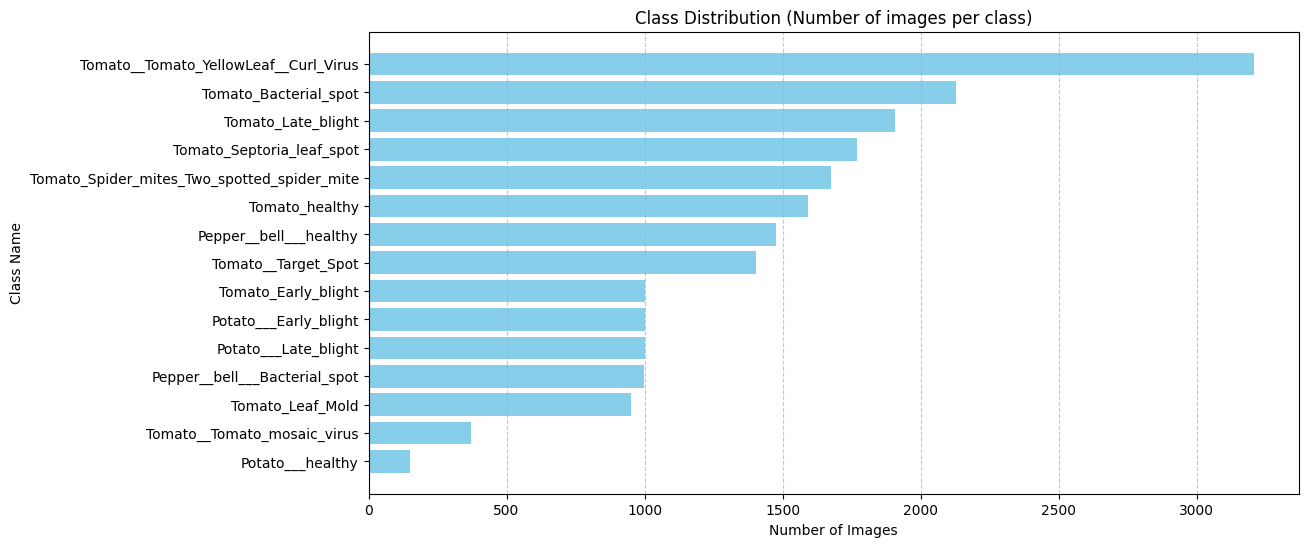

In [10]:
data = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        data.append({'Class': class_name, 'Count': count})

df_dist = pd.DataFrame(data).sort_values(by='Count', ascending=False)

print("Image distribution across classes:")
print(df_dist.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(df_dist['Class'], df_dist['Count'], color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.title('Class Distribution (Number of images per class)')
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Classes Number: 15


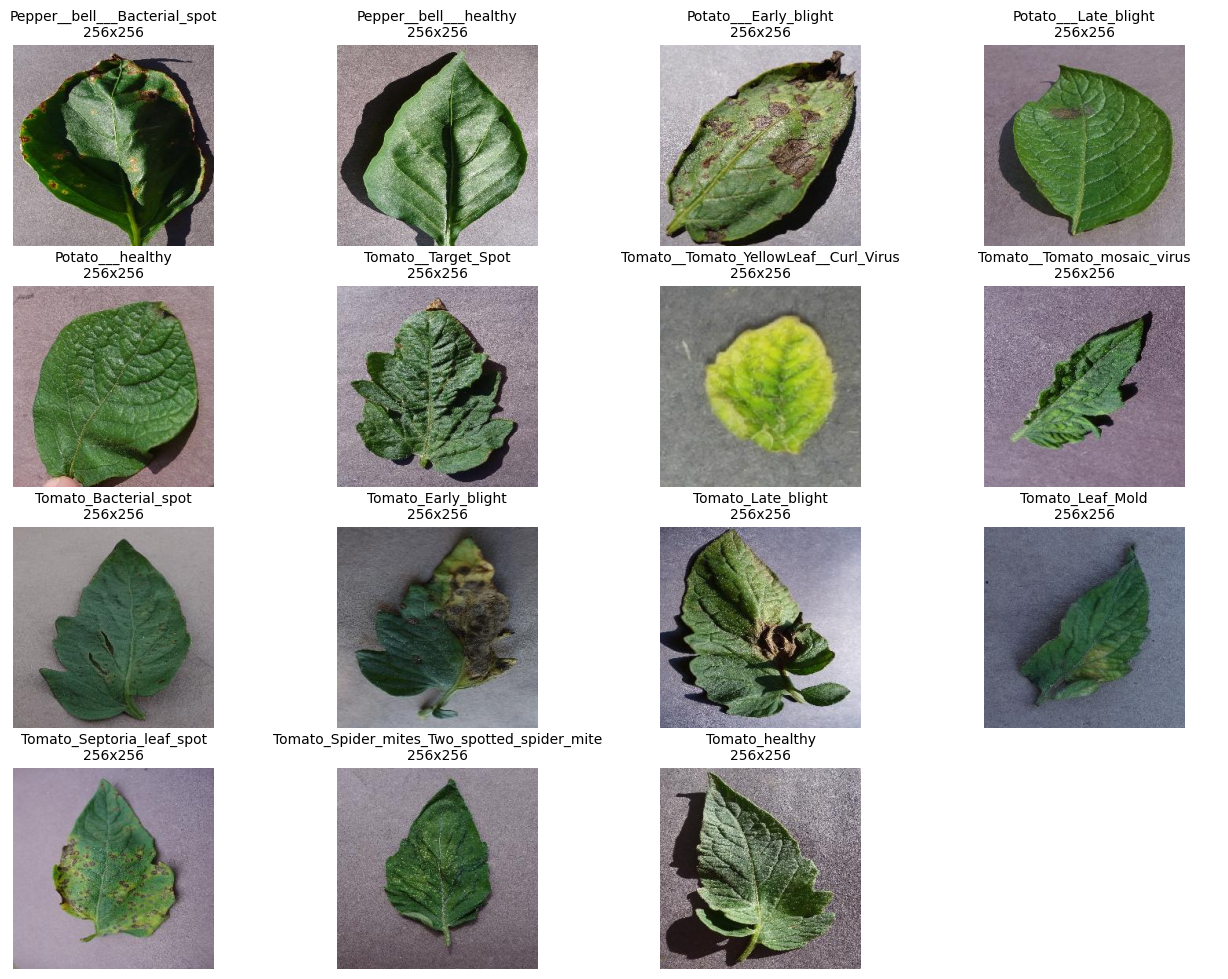

In [11]:
def VisualizeClasses(folders_path):
    # Get all class folders and sort them
    ClassesNames = os.listdir(folders_path)
    ClassesNames.sort(key=lambda x: (x.split('__')[0], x))
    
    # Display the total number of classes
    NUM_CLASSES = len(ClassesNames)
    print(f"Classes Number: {NUM_CLASSES}")
    
    cols = 4
    rows = (NUM_CLASSES + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()
    
    # Show one sample image from each class
    for i, cat in enumerate(ClassesNames):
        ClassFolderPath = os.path.join(folders_path,cat)
        ImagesName = os.listdir(ClassFolderPath)
        img_path = os.path.join(ClassFolderPath,ImagesName[0])
        with Image.open(img_path) as img:
            width, height = img.size
        image = mpimg.imread(img_path)
        axes[i].imshow(image)
        axes[i].set_title(f"{cat}\n{width}x{height}", fontsize=10)
        axes[i].axis('off')
        
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

VisualizeClasses(IMAGES_FOLDERS_PATH) 

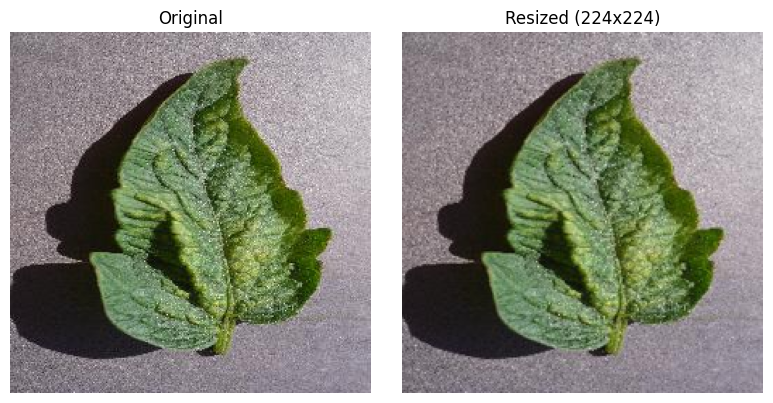

In [12]:
# Pick a random class folder
ClassesNames = os.listdir(IMAGES_FOLDERS_PATH)
random_class = random.choice(ClassesNames)
class_path = os.path.join(IMAGES_FOLDERS_PATH, random_class)

# Pick a random image from that class
images = os.listdir(class_path)
random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

# Open and resize the selected image to 224x224
with Image.open(img_path) as img:
    resized_img = img.resize((WIDTH, HEIGHT)) 

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mpimg.imread(img_path))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(resized_img)
axes[1].set_title(f"Resized ({WIDTH}x{HEIGHT})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

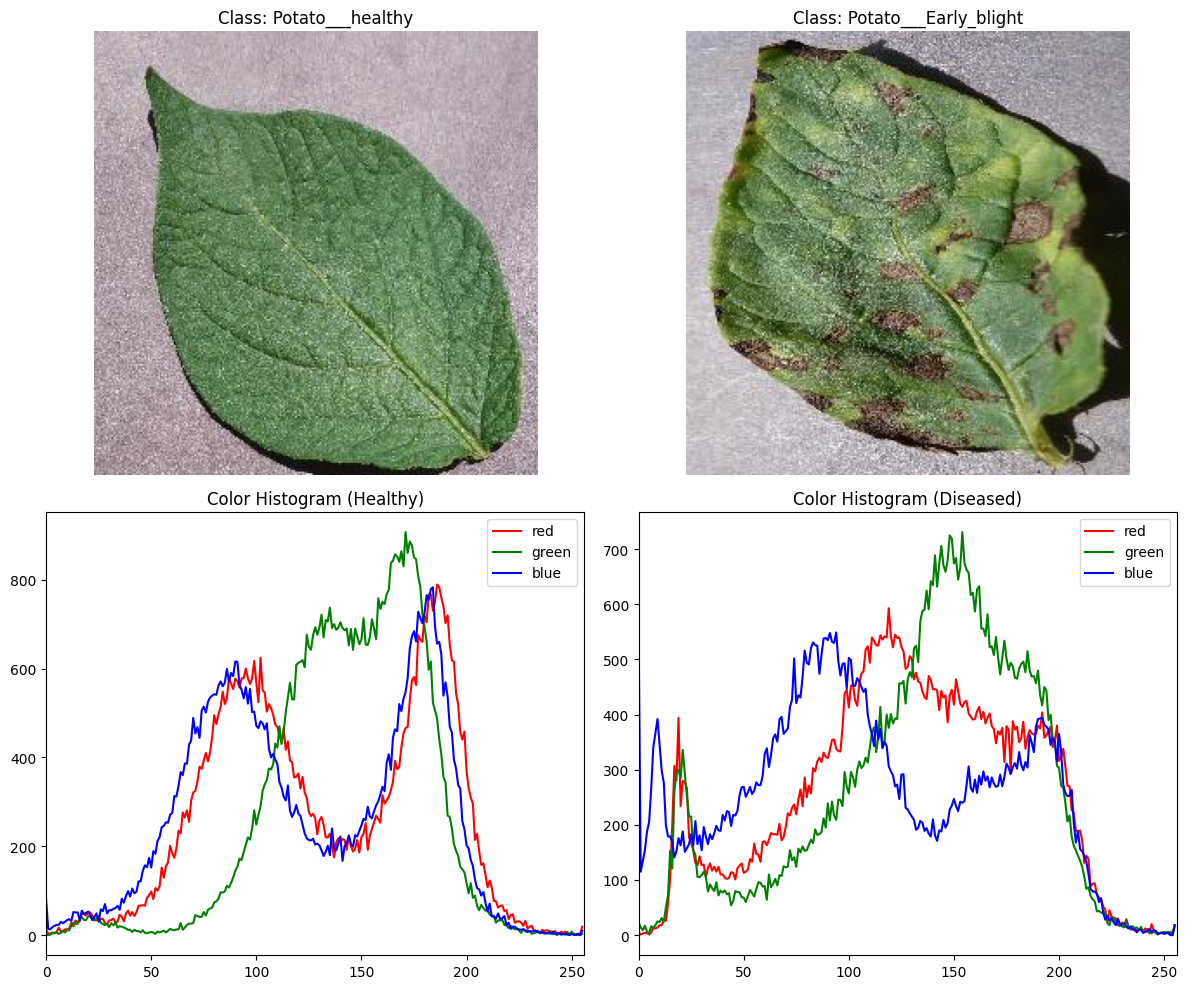

In [13]:
def plot_healthy_vs_diseased(plant_name):
    all_classes = [d for d in os.listdir(IMAGES_FOLDERS_PATH) if d.startswith(plant_name)]
    
    healthy_class = [c for c in all_classes if 'healthy' in c.lower()]
    diseased_classes = [c for c in all_classes if 'healthy' not in c.lower()]
    
    if not healthy_class or not diseased_classes:
        print(f"Couldn't find both healthy and diseased for {plant_name}")
        return

    target_diseased = random.choice(diseased_classes)
    target_healthy = healthy_class[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    for i, class_name in enumerate([target_healthy, target_diseased]):
        class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)
        
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Class: {class_name}")
        axes[0, i].axis('off')
        
        colors = ('red', 'green', 'blue')
        for j, col in enumerate(colors):
            hist = cv2.calcHist([img_rgb], [j], None, [256], [0, 256])
            axes[1, i].plot(hist, color=col, label=col)
            axes[1, i].set_xlim([0, 256])
            
        axes[1, i].set_title(f"Color Histogram ({'Healthy' if i==0 else 'Diseased'})")
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

plot_healthy_vs_diseased('Potato')

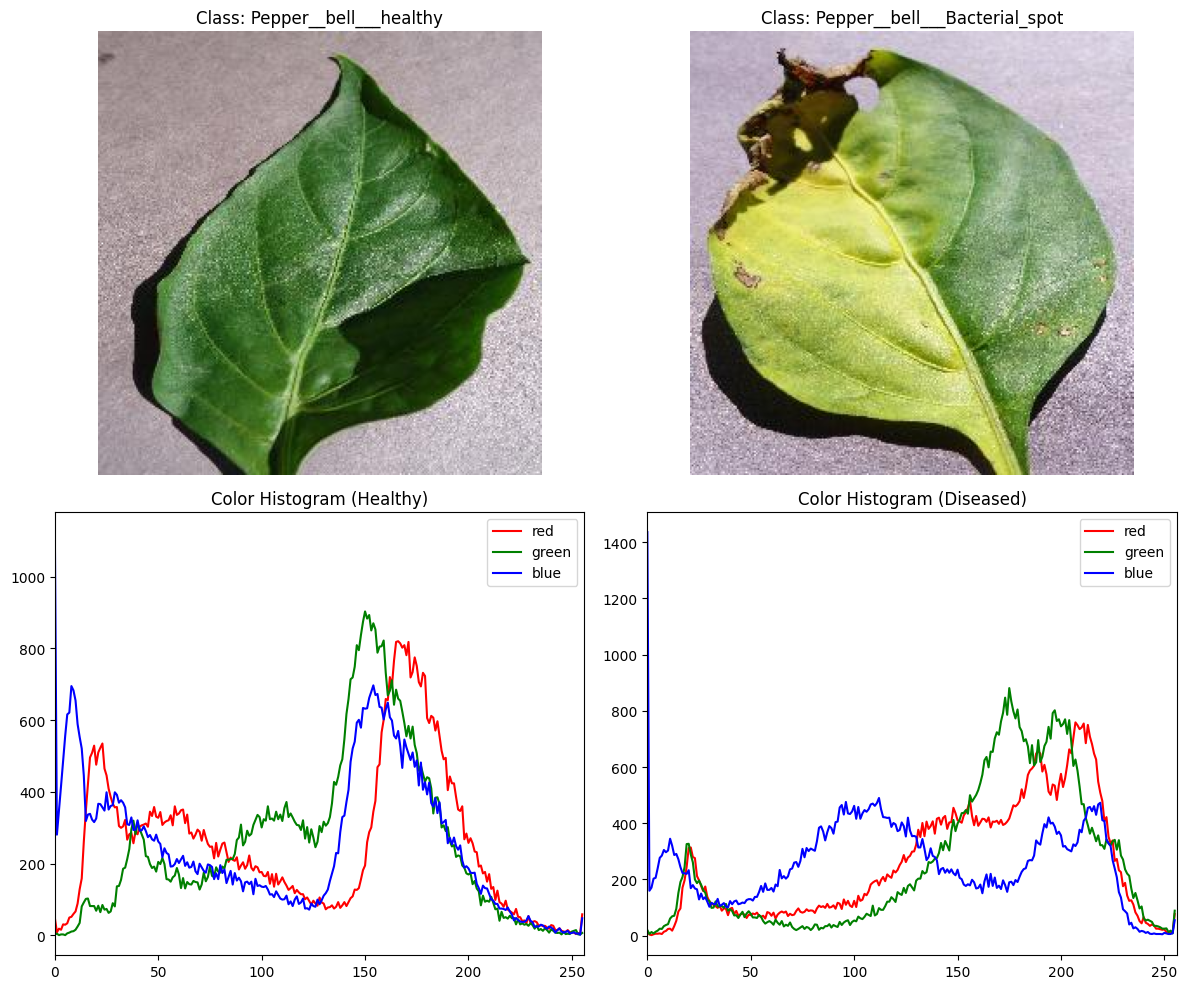

In [14]:
plot_healthy_vs_diseased('Pepper')

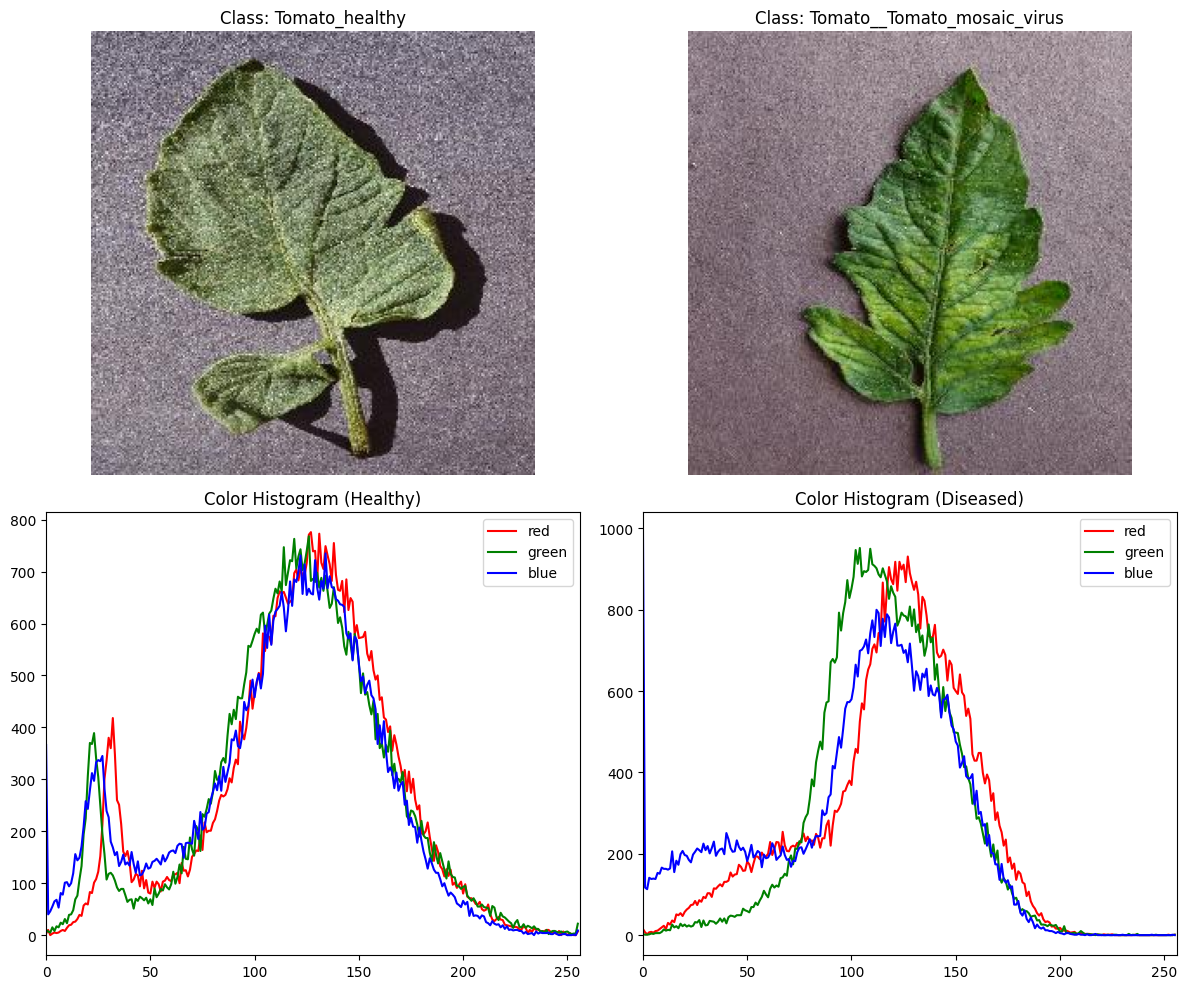

In [15]:
plot_healthy_vs_diseased('Tomato')

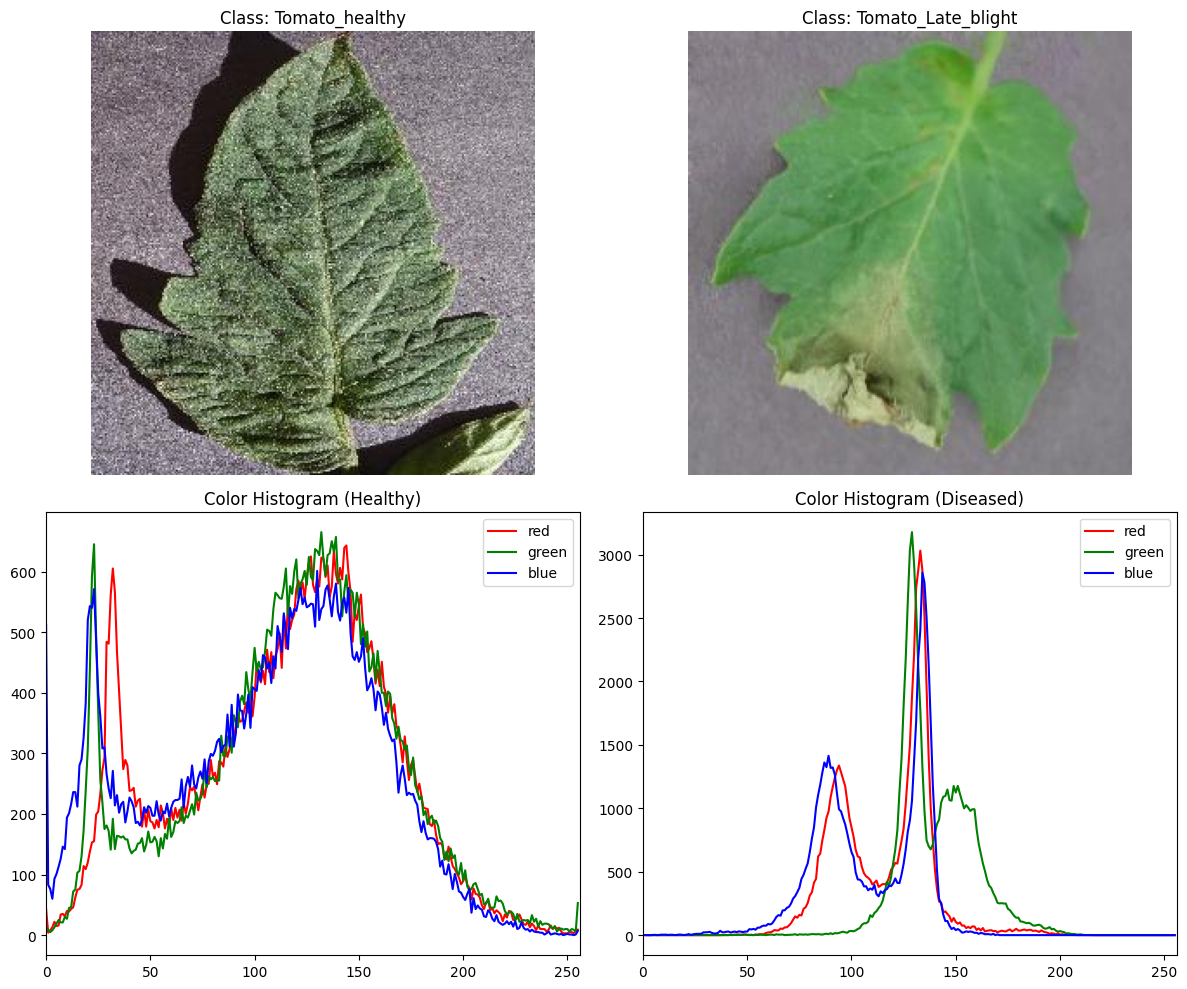

In [16]:
plot_healthy_vs_diseased('Tomato')

In [17]:
splitfolders.ratio(IMAGES_FOLDERS_PATH, output=OUTPUT_FOLDER, seed=42, ratio=(0.8, 0.2))

Copying files: 20639 files [02:10, 158.06 files/s]


In [18]:
def compute_color_histogram(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hist_features = []
    for i in range(3):
        hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        hist_features.extend(hist)
    return hist_features

def compute_texture_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, (WIDTH, HEIGHT))

    lbp = local_binary_pattern(gray, LBP_N_POINTS, LBP_RADIUS, LBP_METHOD)
    n_bins = LBP_N_POINTS + 2
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins,
                                range=(0, n_bins), density=True)

    gray_small = (gray // 4).astype(np.uint8)
    levels = 64
    glcm   = np.zeros((levels, levels), dtype=np.float64)
    glcm[gray_small[:, :-1].ravel(),
         gray_small[:, 1: ].ravel()] += 1
    glcm += glcm.T
    glcm /= glcm.sum()

    i, j  = np.mgrid[0:levels, 0:levels]
    mu    = (i * glcm).sum()
    denom = np.sqrt((glcm * (i - mu)**2).sum()) * \
            np.sqrt((glcm * (j - mu)**2).sum())

    contrast    = (glcm * (i - j)**2).sum()
    energy      = (glcm**2).sum()
    homogeneity = (glcm / (1.0 + (i - j)**2)).sum()
    correlation = (glcm * (i - mu) * (j - mu)).sum() / (denom + 1e-10)

    return list(lbp_hist) + [contrast, energy, homogeneity, correlation]


In [19]:
all_images = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_name in os.listdir(class_path):
        all_images.append((class_name, os.path.join(class_path, img_name)))

print(f"Total images: {len(all_images)}")

Total images: 20639


In [20]:
data = []

for class_name, img_path in tqdm(all_images, desc="Extracting features"):
    color_features   = compute_color_histogram(img_path)
    texture_features = compute_texture_features(img_path)

    if color_features is None or texture_features is None:
        continue

    final_features = color_features + texture_features
    data.append({'class': class_name, 'features': final_features})

df = pd.DataFrame(data)
df.to_pickle('features.pkl')

print(f"Number of Images: {len(df)}")
print(df.head())

Extracting features: 100%|██████████| 20639/20639 [10:12<00:00, 33.72it/s]


Number of Images: 20638
                           class  \
0  Pepper__bell___Bacterial_spot   
1  Pepper__bell___Bacterial_spot   
2  Pepper__bell___Bacterial_spot   
3  Pepper__bell___Bacterial_spot   
4  Pepper__bell___Bacterial_spot   

                                            features  
0  [0.02583752, 0.0077031115, 0.005937815, 0.0083...  
1  [0.006403104, 0.0018294583, 0.0024392777, 0.00...  
2  [0.0007926307, 0.0003170523, 0.00047557845, 0....  
3  [0.00086839765, 0.0007236647, 0.00043419882, 0...  
4  [0.00019173733, 0.0015338986, 0.0007669493, 0....  


In [2]:
df = pd.read_pickle('features.pkl')
X = np.stack(df['features'].values)
y = df['class'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=40, random_state=42) 
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of features after PCA: {X_train_pca.shape[1]}\n")

Original number of features: 798
Number of features after PCA: 40



In [3]:

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
knn_preds = knn.predict(X_test_pca)
print(f"KNN Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")


nb = GaussianNB()
nb.fit(X_train_pca, y_train)
nb_preds = nb.predict(X_test_pca)
print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds) * 100:.2f}%")

KNN Accuracy: 81.13%
Naive Bayes Accuracy: 52.45%


##   Bagging Algorithms

In [ ]:
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [15]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

In [17]:
acc_rf = accuracy_score(y_test,y_pred_rf)
print(f"RandomForest Accuracy: { acc_rf*100:.2f}%")

RandomForest Accuracy: 85.73%


In [ ]:
base_classifier = DecisionTreeClassifier()
#bagging
bagging_classifier = BaggingClassifier(base_classifier ,n_estimators=10,random_state=42)
bagging_classifier.fit(X_train,y_train) 

,estimator,DecisionTreeClassifier()
,n_estimators,10
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,42
,verbose,0


In [24]:
y_pred = bagging_classifier.predict(X_test)
acc_bagging = accuracy_score(y_test,y_pred)
print(f"Bagging Accuracy:{acc_bagging *100:.2f}%")

Bagging Accuracy:80.16%


## Boosting algorthim(adaboost)

In [ ]:
ada = AdaBoostClassifier( estimator=base_classifier,n_estimators=300,learning_rate=0.1 , random_state=42)
ada.fit(X_train ,y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test , y_pred_ada)
print(f"AdaBoost Accuracy: {acc_ada*100:.2f}%")

AdaBoost Accuracy: 65.87%
